# Real vs Bogus — Live Demo

Steps:
1. Sample 500 triplets (stratified)
2. Load and normalise on the fly
3. Train ResNet-18 for 5 epochs
4. Evaluate: ROC, PR, confusion matrix
5. Predict real vs bogus

## 1 - Imports

In [23]:
# Tune
N_DEMO        = 500   # total triplets to sample
EPOCHS        = 5     # training epochs
BATCH_SIZE    = 32     # batch size
LR            = 3e-3
PATIENCE      = 4
RANDOM_SEED   = 42

import sys, warnings, time
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader

from src.models   import RealBogusResNet18
from src.losses   import FocalLoss
from src.dataset  import TransientDataset, make_weighted_sampler, get_augmentation
from src.train    import train_epoch, evaluate_rb
from src.evaluate import (
    full_eval_rb, threshold_analysis,
    plot_roc, plot_pr_curve, plot_confusion_matrix, plot_threshold_curve,
)
from src.utils    import CLASS_NAMES, REAL_BOGUS_MAP, load_fits, prepare_triplet

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROJECT_ROOT = Path('..').resolve()
LABELS_CSV   = PROJECT_ROOT / 'data' / 'labels.csv'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
CLASS_COLOURS = {'SN':'#e34a33','AGN':'#fdbb84','VS':'#2b8cbe',
                 'asteroid':'#31a354','bogus':'#756bb1'}

print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Labels CSV: {LABELS_CSV}')

PyTorch 2.11.0  |  device: cpu
Labels CSV: /Users/antambaye/transient-astronomy/data/labels.csv


## 1 — Sample a small stratified subset

In [24]:
df_full = pd.read_csv(LABELS_CSV)
print(f'Full dataset: {len(df_full):,} rows  |  classes: {sorted(df_full["class"].unique())}')

# Stratified sample: keep class proportions, cap at N_DEMO total
np.random.seed(RANDOM_SEED)
fracs = df_full['class'].value_counts(normalize=True)
parts = []
for cls, frac in fracs.items():
    n = max(int(N_DEMO * frac), 1)  # at least 1 per class
    subset = df_full[df_full['class'] == cls]
    parts.append(subset.sample(min(n, len(subset)), random_state=RANDOM_SEED))

df = pd.concat(parts).sort_values('mjd').reset_index(drop=True)
print(f'\nDemo subset: {len(df):,} rows')
print(df['class'].value_counts().to_string())

rb_counts = df['class'].map(REAL_BOGUS_MAP).value_counts()
print(f'\nReal: {rb_counts.get(1,0):,}   Bogus: {rb_counts.get(0,0):,}')

Full dataset: 4,860 rows  |  classes: ['SN', 'bogus']

Demo subset: 499 rows
class
SN       432
bogus     67

Real: 432   Bogus: 67


## 2 — Quick triplet preview (one per class)

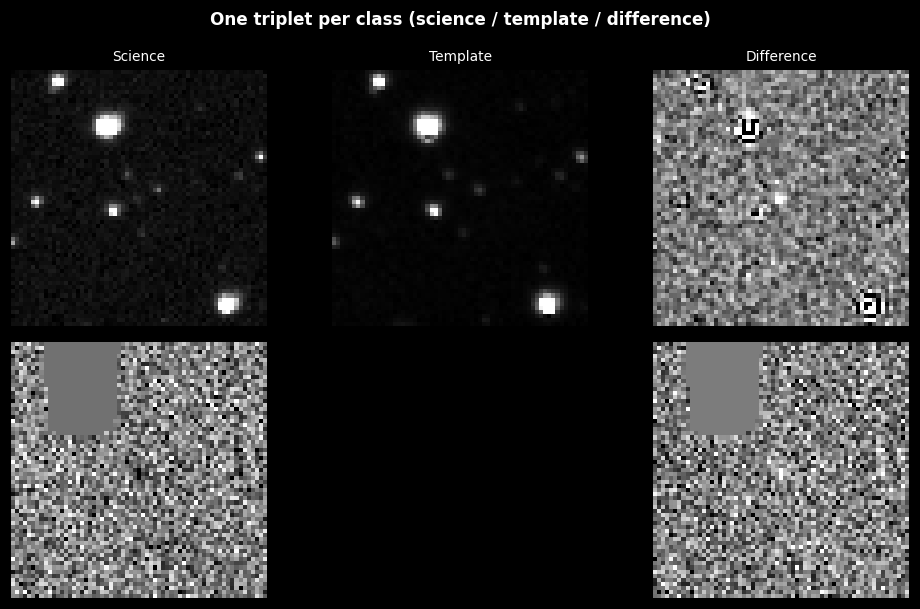

In [25]:
def _resolve(p): return PROJECT_ROOT / str(p).lstrip('/')

classes_to_show = sorted(df['class'].unique())
fig, axes = plt.subplots(len(classes_to_show), 3,
                          figsize=(9, 2.8 * len(classes_to_show)))
if len(classes_to_show) == 1:
    axes = [axes]

stamp_keys = ['science_path', 'template_path', 'difference_path']
stamp_titles = ['Science', 'Template', 'Difference']

for row_axes, cls in zip(axes, classes_to_show):
    row = df[df['class'] == cls].iloc[0]
    for ax, key, title in zip(row_axes, stamp_keys, stamp_titles):
        img = load_fits(_resolve(row[key]))
        img = np.nan_to_num(img); m,s = img.mean(), img.std()
        img_norm = (img - m) / (s if s > 0 else 1)
        vmin, vmax = np.percentile(img_norm, [1, 99])
        ax.imshow(img_norm, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
        if cls == classes_to_show[0]: ax.set_title(title, fontsize=9)
        ax.axis('off')
    row_axes[0].set_ylabel(cls, color=CLASS_COLOURS.get(cls,'k'),
                           fontsize=10, fontweight='bold', labelpad=4)

plt.suptitle('One triplet per class (science / template / difference)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 3 — Time-based split + DataLoaders

Same 70/15/15 chronological split as the full pipeline — no data leakage.

In [26]:
n = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_df = df.iloc[:n_train].reset_index(drop=True)
val_df   = df.iloc[n_train : n_train + n_val].reset_index(drop=True)
test_df  = df.iloc[n_train + n_val :].reset_index(drop=True)

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')
print(f'MJD  train {train_df["mjd"].min():.0f}–{train_df["mjd"].max():.0f}  '
      f'val {val_df["mjd"].min():.0f}–{val_df["mjd"].max():.0f}  '
      f'test {test_df["mjd"].min():.0f}–{test_df["mjd"].max():.0f}')

# Use processed .npy files if available, otherwise load FITS on the fly
proc = PROCESSED if PROCESSED.exists() else None
print(f'\nUsing processed .npy cache: {proc is not None}')

train_ds = TransientDataset(train_df, task='real_bogus',
                            processed_dir=proc,
                            transform=get_augmentation('train'))
val_ds   = TransientDataset(val_df,   task='real_bogus', processed_dir=proc)
test_ds  = TransientDataset(test_df,  task='real_bogus', processed_dir=proc)

sampler = make_weighted_sampler(train_ds.labels)

# Use num_workers=0 to avoid multiprocessing overhead in demo
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0)

x, y = next(iter(train_loader))
print(f'Batch shape: {tuple(x.shape)}  labels: {y.unique().tolist()}')

Train: 349  Val: 74  Test: 76
MJD  train 58376–60564  val 60576–60725  test 60731–61134

Using processed .npy cache: False
Batch shape: (32, 3, 63, 63)  labels: [0, 1]


## 4 — Train ResNet-18 (fast run)

Same architecture as the full pipeline — modified 3×3 stem, FocalLoss, AdamW.

In [27]:
from torch.cuda.amp import GradScaler

torch.manual_seed(RANDOM_SEED)
model     = RealBogusResNet18().to(DEVICE)
criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = GradScaler(enabled=DEVICE.type == 'cuda')

history = []
best_auc, best_state, no_improve = -1.0, None, 0

print(f'Training for up to {EPOCHS} epochs  (patience={PATIENCE})\n')
print(f'{"Epoch":>6}  {"Train Loss":>11}  {"Val AUC":>9}  {"Val AP":>8}  {"Time":>6}')
print('-' * 50)

for epoch in range(1, EPOCHS + 1):
    t0 = time.perf_counter()
    tr = train_epoch(model, train_loader, optimizer, criterion, scaler,
                     DEVICE, task='real_bogus')
    vl = evaluate_rb(model, val_loader, DEVICE, criterion)
    scheduler.step()

    history.append({'epoch': epoch, 'train_loss': tr['loss'],
                    'val_auc': vl['auc'], 'val_ap': vl['ap'],
                    'lr': optimizer.param_groups[0]['lr']})

    elapsed = time.perf_counter() - t0
    flag = '  ★' if vl['auc'] > best_auc else ''
    print(f'{epoch:>6}  {tr["loss"]:>11.4f}  {vl["auc"]:>9.4f}  '
          f'{vl["ap"]:>8.4f}  {elapsed:>5.1f}s{flag}')

    if vl['auc'] > best_auc:
        best_auc = vl['auc']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\nEarly stopping (patience={PATIENCE})')
            break

# Restore best weights
model.load_state_dict(best_state)
print(f'\nBest val AUC: {best_auc:.4f}')

Training for up to 5 epochs  (patience=4)

 Epoch   Train Loss    Val AUC    Val AP    Time
--------------------------------------------------
     1       0.1594     0.4921    0.8493   16.2s  ★
     2       0.0397     0.5231    0.8803   14.3s  ★
     3       0.0365     0.8802    0.9780   18.1s  ★
     4       0.0347     0.9163    0.9859   16.4s  ★
     5       0.0269     0.9322    0.9889   15.8s  ★

Best val AUC: 0.9322


## 5 — Training curves

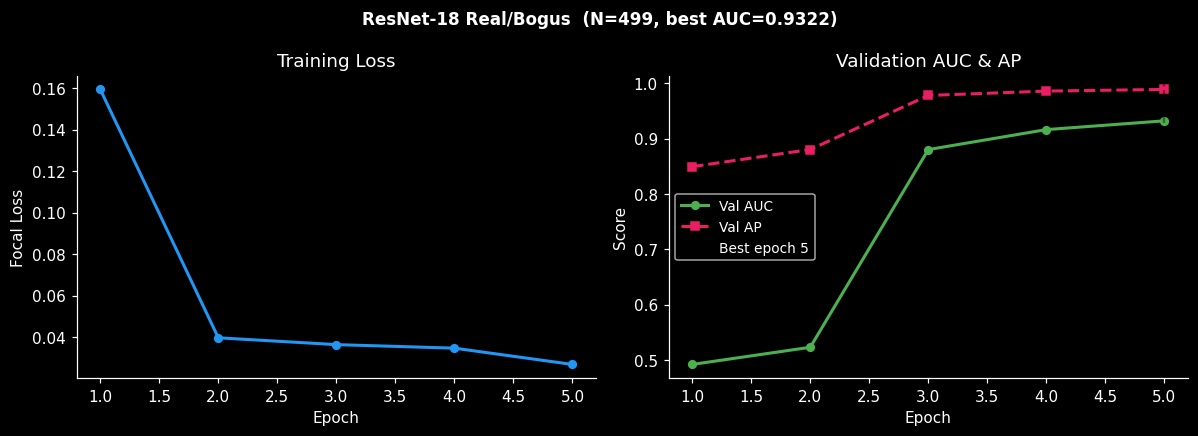

In [28]:
epochs_x   = [h['epoch']     for h in history]
train_loss = [h['train_loss'] for h in history]
val_auc    = [h['val_auc']   for h in history]
val_ap     = [h['val_ap']    for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs_x, train_loss, 'o-', color='#2196F3', lw=2, ms=5)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Focal Loss')
ax1.set_title('Training Loss')

ax2.plot(epochs_x, val_auc, 'o-', color='#4CAF50', lw=2, ms=5, label='Val AUC')
ax2.plot(epochs_x, val_ap,  's--',color='#E91E63', lw=2, ms=5, label='Val AP')
best_ep = max(history, key=lambda h: h['val_auc'])['epoch']
ax2.axvline(best_ep, color='k', linestyle='--', alpha=0.4,
            label=f'Best epoch {best_ep}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_title('Validation AUC & AP')
ax2.legend(fontsize=9)

plt.suptitle(f'ResNet-18 Real/Bogus  (N={len(df):,}, best AUC={best_auc:.4f})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 — Evaluate on test set

In [29]:
test_stats = evaluate_rb(model, test_loader, DEVICE)
probs  = test_stats['probs']
labels = test_stats['labels']

metrics = full_eval_rb(probs, labels, threshold=0.5)
ta      = threshold_analysis(probs, labels, target_recall=0.95)
metrics_op = full_eval_rb(probs, labels, threshold=ta['operating_threshold'])

print(f'Test samples : {len(labels):,}')
print(f'Positive rate: {labels.mean()*100:.1f}%')
print()
print(f'AUC-ROC : {metrics["auc"]:.4f}   (braai baseline: ~0.99)')
print(f'Avg Prec: {metrics["ap"]:.4f}')
print(f'F1 at 0.5 : {metrics["f1"]:.4f}')
print()
print(f'Operating point (recall≥0.95):')
print(f'  Threshold : {ta["operating_threshold"]:.4f}')
print(f'  Precision : {metrics_op["precision"]:.4f}')
print(f'  Recall    : {metrics_op["recall"]:.4f}')
print(f'  F1        : {metrics_op["f1"]:.4f}')

Test samples : 76
Positive rate: 76.3%

AUC-ROC : 0.8506   (braai baseline: ~0.99)
Avg Prec: 0.9429
F1 @0.5 : 0.8545

Operating point (recall≥0.95):
  Threshold : 0.4098
  Precision : 0.8261
  Recall    : 0.9828
  F1        : 0.8976


## 7 — Plots: ROC, PR curve, Confusion matrix, Threshold

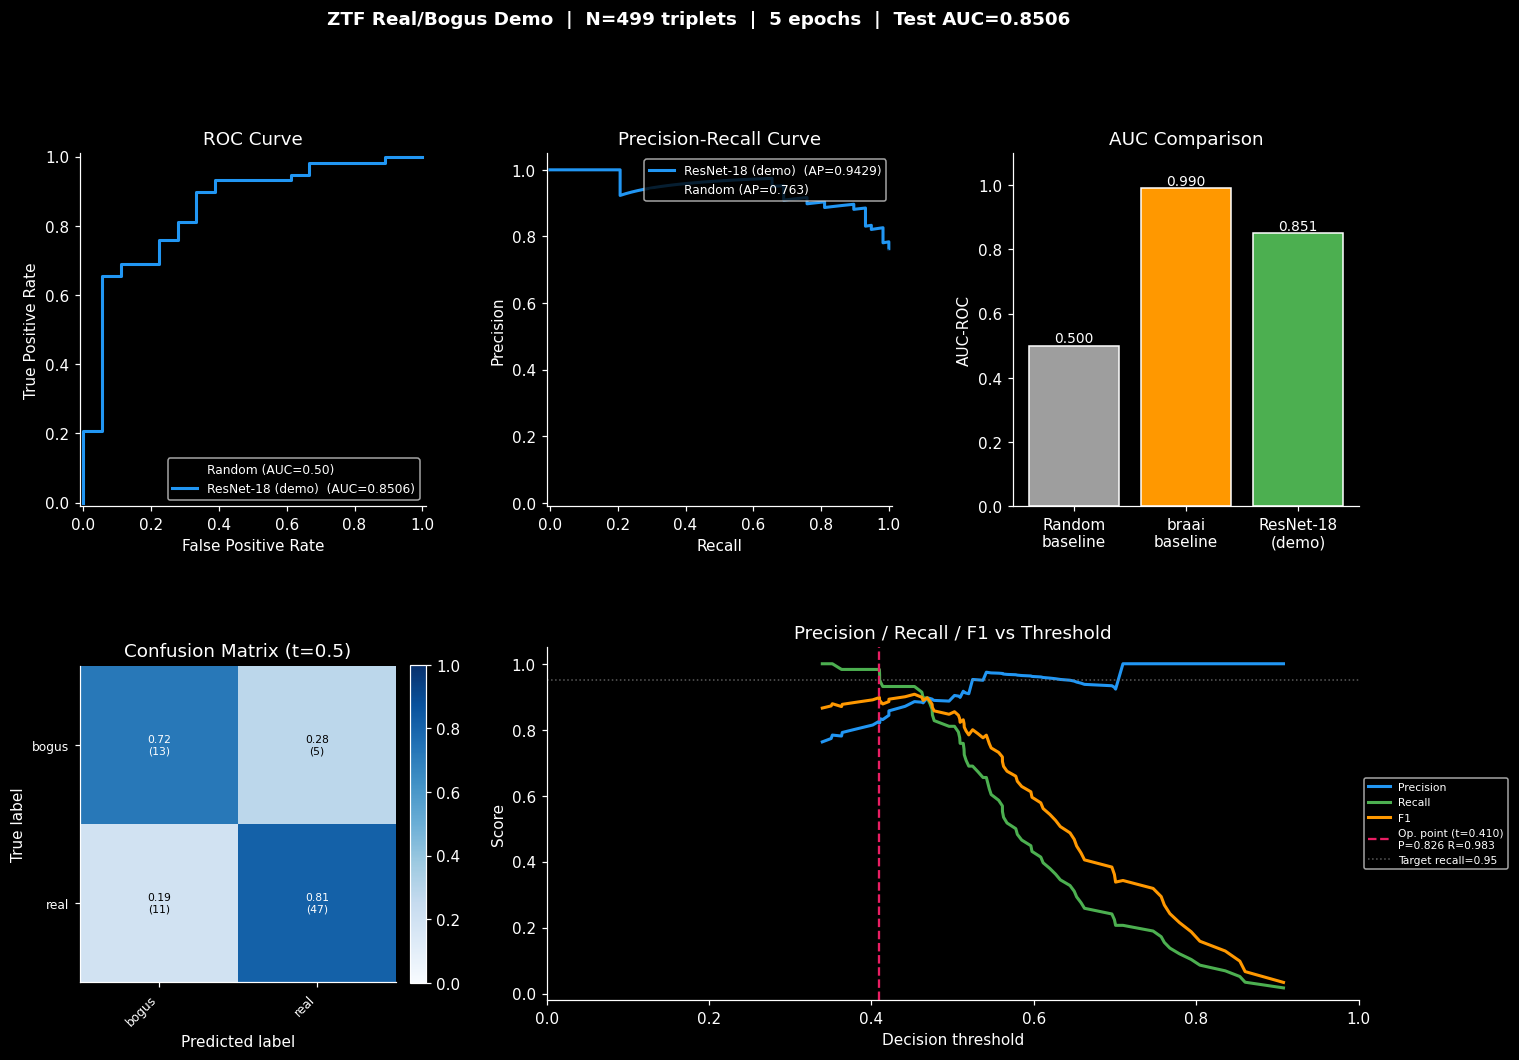

In [34]:
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ROC
ax_roc = fig.add_subplot(gs[0, 0])
plot_roc({'ResNet-18 (demo)': (probs, labels)}, ax=ax_roc,
         title='ROC Curve')

# Precision-Recall curve
ax_pr = fig.add_subplot(gs[0, 1])
plot_pr_curve({'ResNet-18 (demo)': (probs, labels)}, ax=ax_pr,
              title='Precision-Recall Curve')

# AUC
ax_bar = fig.add_subplot(gs[0, 2])
auc_names = ['Random\nbaseline', 'braai\nbaseline', 'ResNet-18\n(demo)']
auc_vals  = [0.50, 0.99, metrics['auc']]
auc_clrs  = ['#9E9E9E', '#FF9800', '#4CAF50' if metrics['auc'] > 0.85 else '#2196F3']
bars = ax_bar.bar(auc_names, auc_vals, color=auc_clrs, edgecolor='white')
for bar, v in zip(bars, auc_vals):
    ax_bar.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', fontsize=9)
ax_bar.set_ylim(0, 1.1); ax_bar.set_ylabel('AUC-ROC')
ax_bar.set_title('AUC Comparison')

# Confusion matrix (threshold=0.5)
ax_cm = fig.add_subplot(gs[1, 0])
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(labels, (probs >= 0.5).astype(int))
plot_confusion_matrix(cm, ['bogus','real'], ax=ax_cm,
                      title='Confusion Matrix (t=0.5)', normalize=True)

# Threshold curve
ax_thr = fig.add_subplot(gs[1, 1:])
plot_threshold_curve(probs, labels, ax=ax_thr, target_recall=0.95,
                     title='Precision / Recall / F1 vs Threshold')

plt.suptitle(
    f'ZTF Real/Bogus Demo  |  N={len(df):,} triplets  |  '
    f'{EPOCHS} epochs  |  Test AUC={metrics["auc"]:.4f}',
    fontsize=12, fontweight='bold', y=1.01
)
plt.show()

## 8 — Few examples

High-confidence errors are the most instructive for a demo audience.

False positives (bogus → real): 5
False negatives (real → bogus): 11


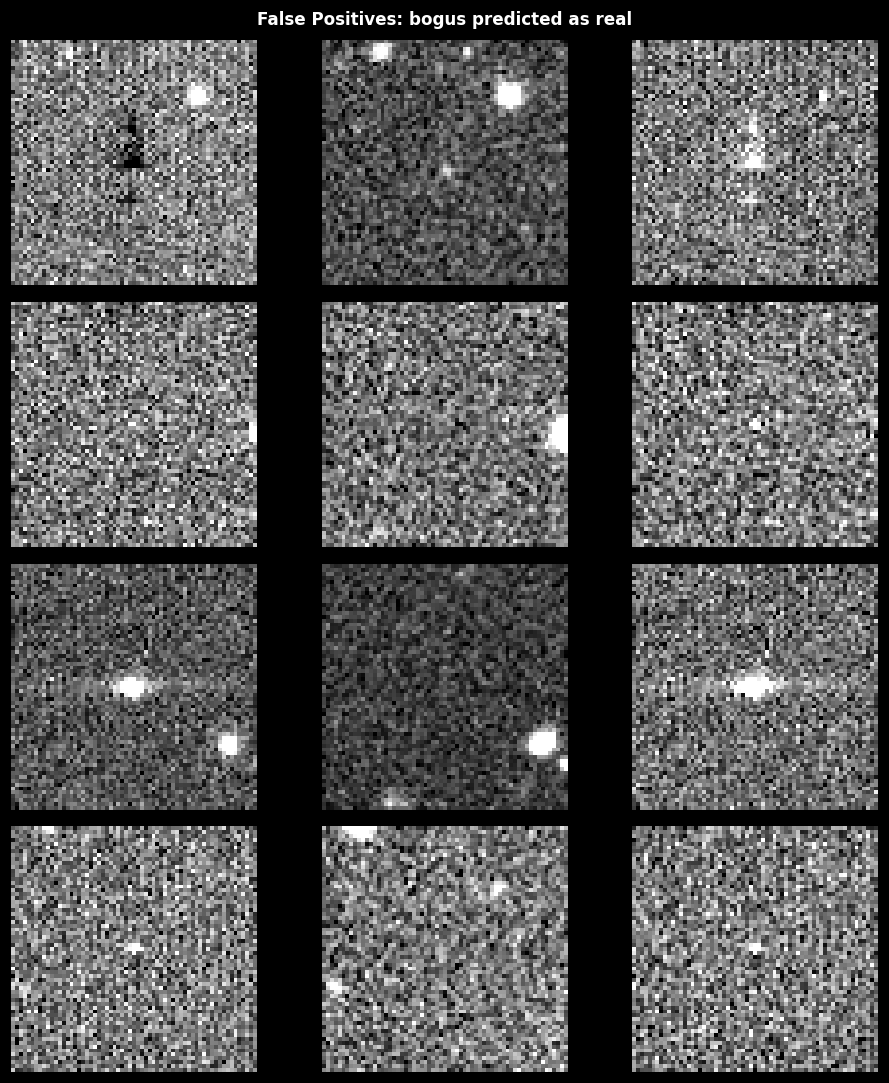

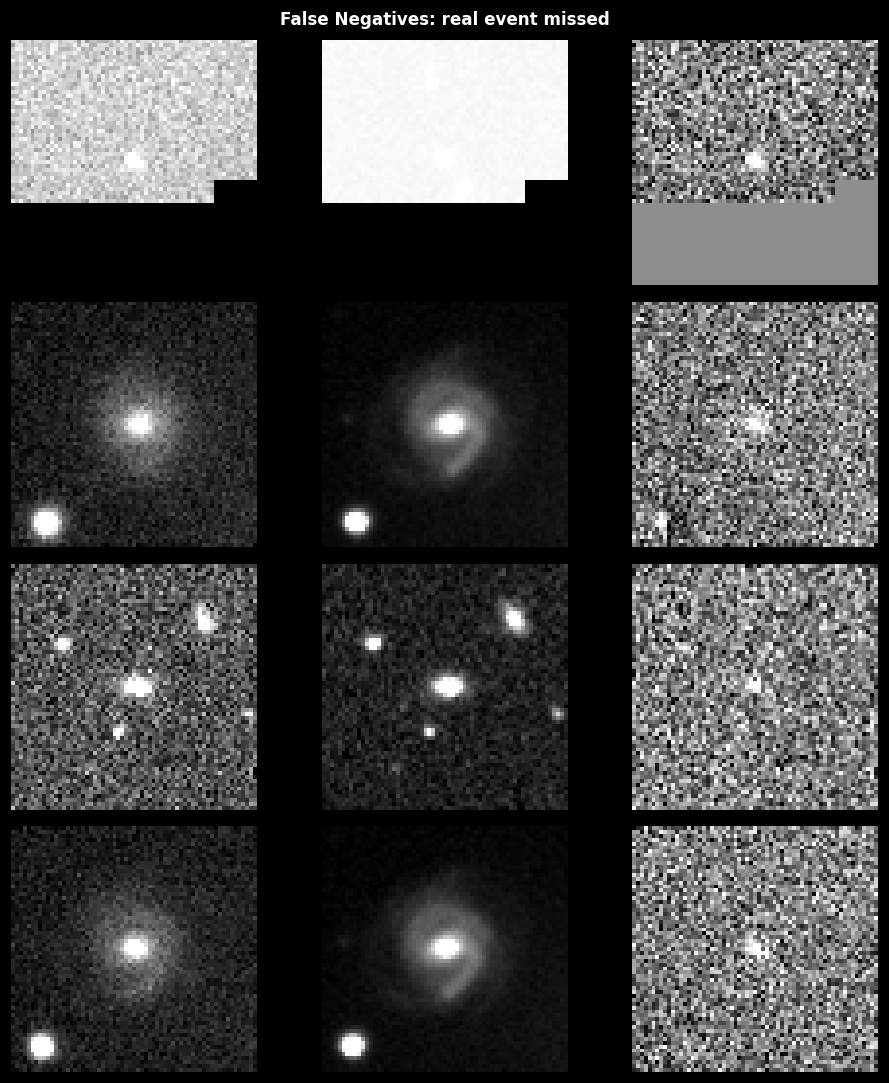

In [31]:
# Collect indices of the worst false positives and false negatives
preds_05 = (probs >= 0.5).astype(int)

false_pos_idx = np.where((preds_05 == 1) & (labels == 0))[0]  # bogus predicted real
false_neg_idx = np.where((preds_05 == 0) & (labels == 1))[0]  # real predicted bogus

print(f'False positives (bogus → real): {len(false_pos_idx):,}')
print(f'False negatives (real → bogus): {len(false_neg_idx):,}')

def show_errors(idx_list, title, n_show=4):
    if len(idx_list) == 0:
        print(f'No {title} to show.')
        return
    # Sort by confidence (most wrong first)
    conf = np.abs(probs[idx_list] - 0.5)
    top = idx_list[np.argsort(conf)[::-1][:n_show]]

    fig, axes = plt.subplots(n_show, 3, figsize=(9, 2.5 * n_show))
    if n_show == 1: axes = [axes]
    for ax_row, ds_idx in zip(axes, top):
        row = test_df.iloc[ds_idx]
        for ax, key in zip(ax_row,
                           ['science_path','template_path','difference_path']):
            img = load_fits(_resolve(row[key]))
            img = np.nan_to_num(img); m,s = img.mean(), img.std()
            img_n = (img-m)/(s if s>0 else 1)
            vmin,vmax = np.percentile(img_n,[1,99])
            ax.imshow(img_n, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
            ax.axis('off')
        true_cls = row['class']
        p = probs[ds_idx]
        ax_row[0].set_ylabel(
            f'True: {true_cls}\nP(real)={p:.3f}',
            color=CLASS_COLOURS.get(true_cls,'k'), fontsize=8)
    plt.suptitle(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_errors(false_pos_idx, 'False Positives: bogus predicted as real')
show_errors(false_neg_idx, 'False Negatives: real event missed')

## 9 - Prediction?

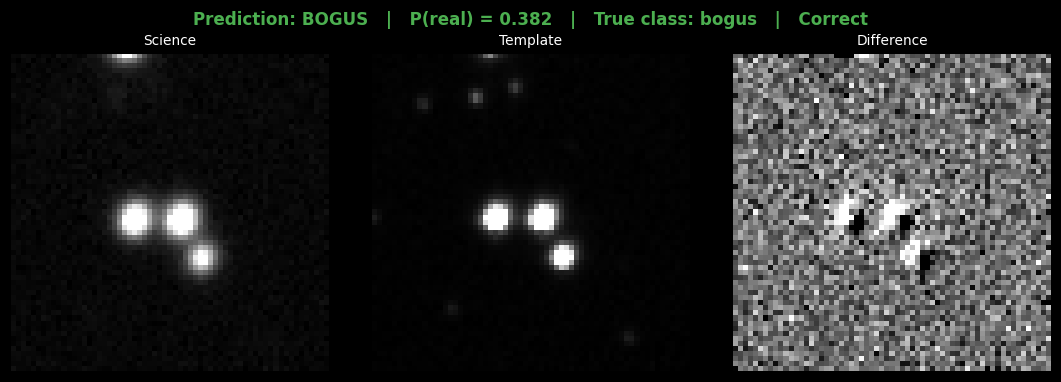

  P(real):  0.382
  Verdict: BOGUS
  True: bogus  (bogus)
  Correct: Yes


In [40]:
# Prediction index
PREDICT_IDX = 2


if PREDICT_IDX is None:
    PREDICT_IDX = np.random.randint(0, len(test_df))

row = test_df.iloc[PREDICT_IDX]
true_label = REAL_BOGUS_MAP[row['class']]
true_class = row['class']

# Load and preprocess the triplet
sci  = load_fits(_resolve(row['science_path']))
tmpl = load_fits(_resolve(row['template_path']))
diff = load_fits(_resolve(row['difference_path']))
triplet = prepare_triplet(sci, tmpl, diff)
x_input = torch.tensor(triplet).unsqueeze(0).to(DEVICE)

# Run inference
model.eval()
with torch.no_grad():
    p_real = float(torch.sigmoid(model(x_input)).cpu())

verdict  = 'REAL' if p_real >= 0.5 else 'BOGUS'
correct  = (p_real >= 0.5) == bool(true_label)


# Plot the triplet
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, img_raw, title in zip(axes, [sci, tmpl, diff],
                               ['Science', 'Template', 'Difference']):
    img = np.nan_to_num(img_raw)
    m, s = img.mean(), img.std()
    img_n = (img - m) / (s if s > 0 else 1)
    vmin, vmax = np.percentile(img_n, [1, 99])
    ax.imshow(img_n, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle(
    f'Prediction: {verdict}   |   P(real) = {p_real:.3f}   |   '
    f'True class: {true_class}   |   {"Correct" if correct else "Wrong"}',
    fontsize=11, fontweight='bold',
    color='#4CAF50' if correct else '#e34a33'
)
plt.tight_layout()
plt.show()

print(f'  P(real):  {p_real:.3f}')
print(f'  Verdict: {verdict}')
print(f'  True: {true_class}  ({"real" if true_label else "bogus"})')
print(f'  Correct: {"Yes" if correct else "No"}')

## 10 — Summary

In [33]:
from tabulate import tabulate

config = [
    ['Dataset',   f'{len(df):,} triplets (sampled from 123K)'],
    ['Split',     '70/15/15 time-based (no leakage)'],
    ['Model',     'ResNet-18 (3×3 stem, 11.2M params)'],
    ['Loss',      'FocalLoss(alpha=0.25, gamma=2.0)'],
    ['Sampler',   'WeightedRandomSampler'],
    ['Epochs',    f'{len(history)}/{EPOCHS}'],
]

results = [
    ['Test AUC-ROC',         f'{metrics["auc"]:.4f}',              '~0.99 (braai)'],
    ['Test AP',              f'{metrics["ap"]:.4f}',               '—'],
    ['F1 @ 0.5',             f'{metrics["f1"]:.4f}',               '—'],
    ['Operating threshold',  f'{ta["operating_threshold"]:.4f}',   '—'],
    ['Recall @ op. thr',     f'{metrics_op["recall"]:.4f}',        '≥ 0.95'],
    ['Precision @ op. thr',  f'{metrics_op["precision"]:.4f}',     '—'],
]

print(tabulate(config,  headers=['Configuration', 'Value'],          tablefmt='rounded_outline'))
print()
print(tabulate(results, headers=['Metric', 'Value', 'Target'],       tablefmt='rounded_outline'))

╭─────────────────┬────────────────────────────────────╮
│ Configuration   │ Value                              │
├─────────────────┼────────────────────────────────────┤
│ Dataset         │ 499 triplets (sampled from 123K)   │
│ Split           │ 70/15/15 time-based (no leakage)   │
│ Model           │ ResNet-18 (3×3 stem, 11.2M params) │
│ Loss            │ FocalLoss(alpha=0.25, gamma=2.0)   │
│ Sampler         │ WeightedRandomSampler              │
│ Epochs          │ 5/5                                │
╰─────────────────┴────────────────────────────────────╯

╭─────────────────────┬─────────┬───────────────╮
│ Metric              │   Value │ Target        │
├─────────────────────┼─────────┼───────────────┤
│ Test AUC-ROC        │  0.8506 │ ~0.99 (braai) │
│ Test AP             │  0.9429 │ —             │
│ F1 @ 0.5            │  0.8545 │ —             │
│ Operating threshold │  0.4098 │ —             │
│ Recall @ op. thr    │  0.9828 │ ≥ 0.95        │
│ Precision @ op. thr │  0.82